In [93]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
df_train = pd.read_csv('train')
df_test = pd.read_csv('test')
sub_sample = pd.read_csv('sample_submission')

In [95]:
df_train.head()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0


In [96]:
df_test.head()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user
0,7001,11,71.085651,31,14,3613.133197,20,12.307634,0
1,1319,9,47.558578,23,13,6189.807969,24,5.585591,1
2,8901,10,79.631917,19,16,7425.979316,16,15.729078,1
3,9175,11,54.990557,21,14,5058.609732,26,9.082133,1
4,350,1,54.626764,3,9,5477.624691,15,11.273880,0


In [97]:
sub_sample.head()

,id,retention
0,7001,0
1,1319,0
2,8901,0
3,9175,0
4,350,0


In [98]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7595 entries, 0 to 7594
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7595 non-null   int64  
 1   sessions_count            7595 non-null   int64  
 2   avg_session_time          7595 non-null   float64
 3   days_since_last_activity  7595 non-null   int64  
 4   purchases_count           7595 non-null   int64  
 5   avg_purchase_value        7595 non-null   float64
 6   active_days               7595 non-null   int64  
 7   session_std               7595 non-null   float64
 8   is_weekend_user           7595 non-null   int64  
 9   retention                 7595 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 593.5 KB


In [99]:
df_train.duplicated().sum()


np.int64(0)

In [100]:
print("Sesssion Count")
df_train.sessions_count.unique()

Sesssion Count


array([16,  1,  8, 13, 12, 11, 15,  3, 14, 10, 17,  4, 20,  9, 18,  2,  5,
        7,  6, 22, 23, 21, 19, 25, 27, 31, 30, 24, 26, 29, 28])

In [101]:
df_train.columns

Index(['id', 'sessions_count', 'avg_session_time', 'days_since_last_activity',
       'purchases_count', 'avg_purchase_value', 'active_days', 'session_std',
       'is_weekend_user', 'retention'],
      dtype='str')

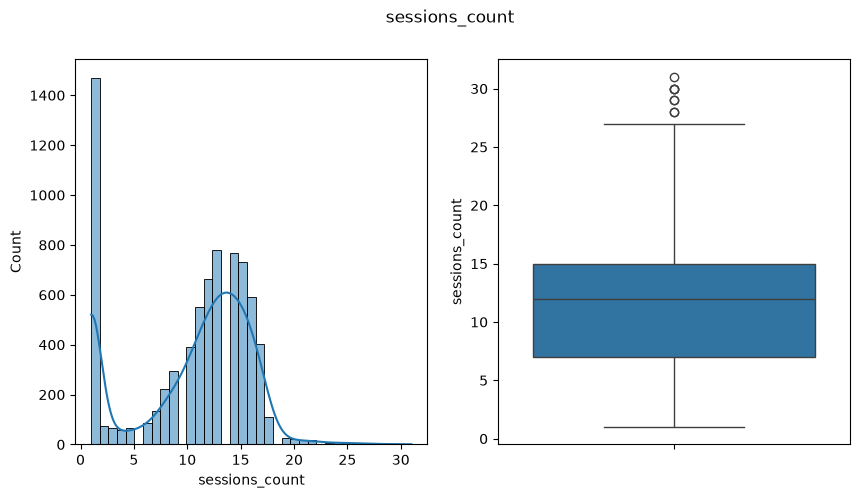

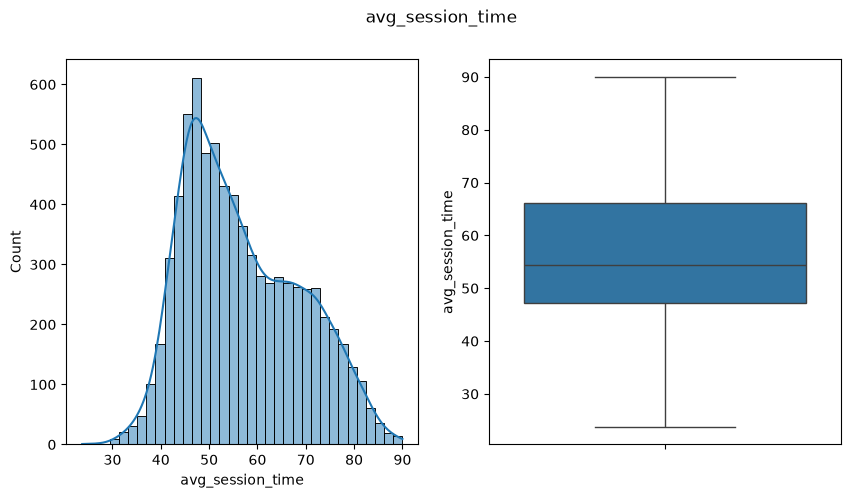

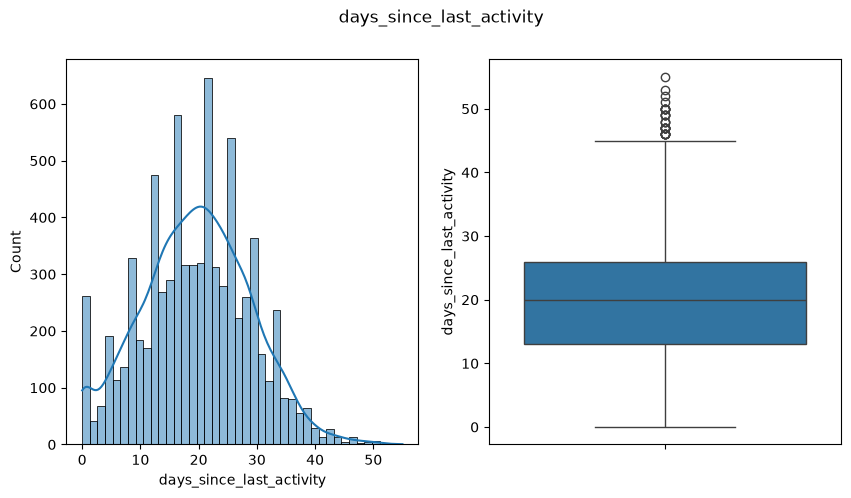

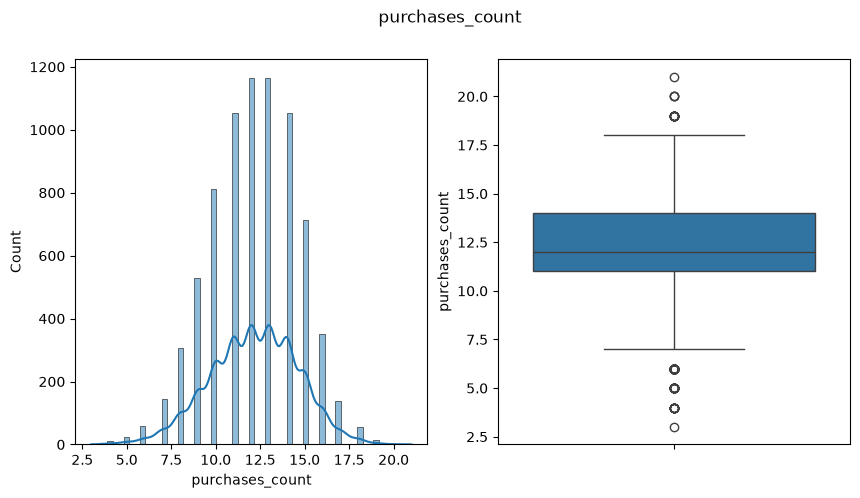

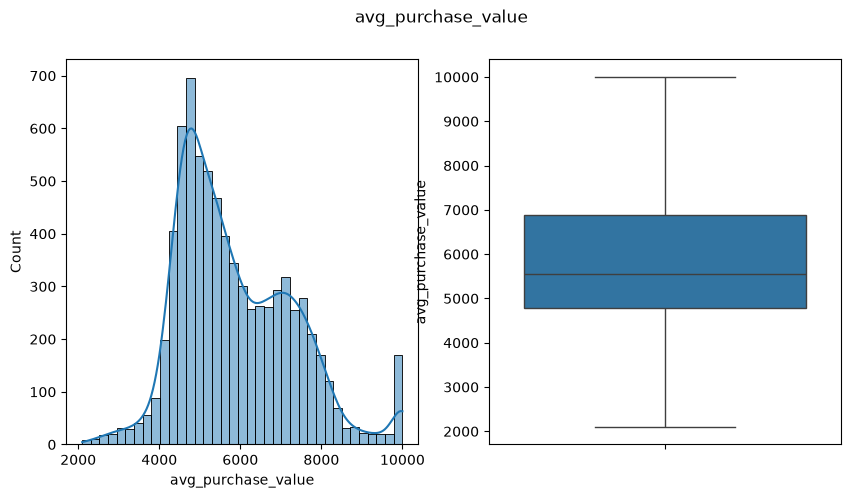

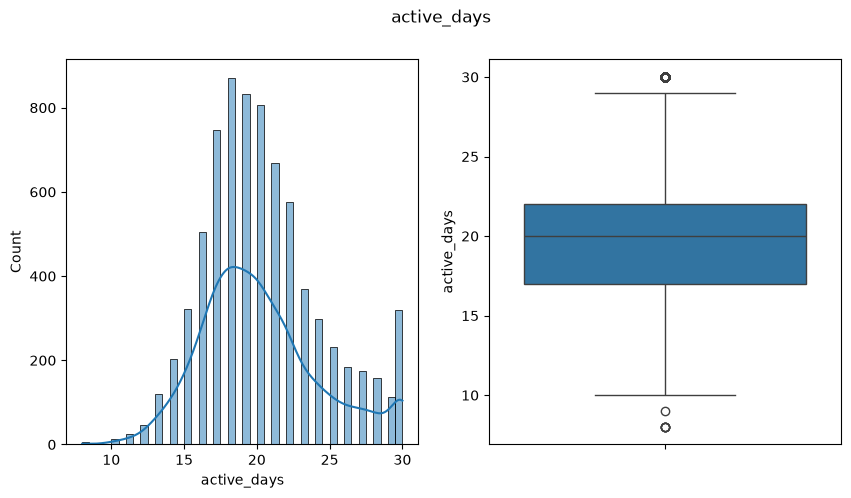

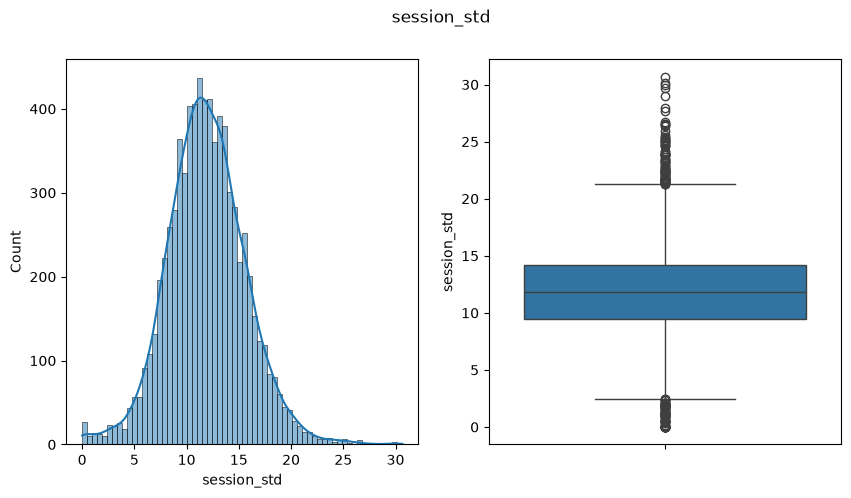

In [102]:
cols = ['sessions_count', 'avg_session_time', 'days_since_last_activity', 'purchases_count', 'avg_purchase_value', 'active_days','session_std'] 
 
for col in cols:
    fig,ax = plt.subplots(1,2 ,figsize =(10,5))
    sns.histplot(df_train[col], kde=True, ax = ax[0])
    sns.boxplot(df_train[col], ax = ax[1] )
    plt.suptitle(col)
    plt.show()
 


In [103]:
# Which feature is the most important 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

x_train,x_test, y_train,y_test = train_test_split(df_train.drop(['id','retention'],axis=1), df_train.retention, test_size=0.2, random_state=42)

rnf = RandomForestClassifier(random_state=42)
rnf.fit(x_train,y_train)
print(x_train.columns)
print(rnf.feature_importances_*100)

# important features = 

# avg_session_time = 18.64
# sessions_count  10.64237563
# days_since_last_activity = 13.68881576
# session_std = 17.1036
# avg_purchase_value 18.73
# active_days = 7.85



Index(['sessions_count', 'avg_session_time', 'days_since_last_activity',
       'purchases_count', 'avg_purchase_value', 'active_days', 'session_std',
       'is_weekend_user'],
      dtype='str')
[10.64237563 18.85023793 13.68881576  7.85456434 18.73219958 10.59331181
 17.10360576  2.5348892 ]


In [104]:
df_logistic = df_train[['avg_session_time', 'sessions_count', 'days_since_last_activity', 'session_std', 'avg_purchase_value', 'active_days','is_weekend_user', 'purchases_count']]
df_logistic.head()

,avg_session_time,sessions_count,days_since_last_activity,session_std,avg_purchase_value,active_days,is_weekend_user,purchases_count
0,46.079173,16,9,14.307116,5462.010418,18,1,13
1,42.625268,1,24,26.690708,4679.746955,14,1,8
2,67.310472,16,21,13.092315,6532.157783,21,1,12
3,78.904027,16,34,10.564979,7155.049697,28,0,14
4,50.456513,8,19,6.813272,6214.569079,25,1,12


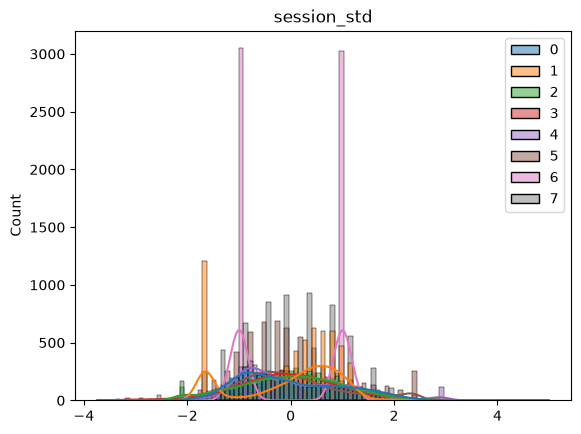

In [105]:
from sklearn.preprocessing import StandardScaler

x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(df_logistic, df_train.retention, test_size=0.2 , random_state=42)


scaler = StandardScaler()
# scaler.fit(x_train_log,y_train_log)
x_train_log_scaled = scaler.fit_transform(x_train_log)
x_test_log_scaled = scaler.transform(x_test_log)

# for col in x_train_log:
    # fig,ax = plt.subplots(1,2 ,figsize =(10,5))
sns.histplot(x_train_log_scaled[:], kde=True)
    # sns.boxplot(df_train[col], ax = ax[1] )
    # plt.suptitle(col)
plt.title(col)
plt.show()
 

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

log = LogisticRegression(solver='saga',max_iter=10000, l1_ratio=1, C=0.1)
log.fit(x_train_log_scaled,y_train_log)
y_pred_log_prob = log.predict_proba(x_test_log_scaled)
y_pred_log = log.predict(x_test_log_scaled)
print("Accuracy score",accuracy_score(y_test_log,y_pred_log))
print("Roc_auc_curve", roc_auc_score(y_test_log, y_pred_log_prob[:,1]))

Accuracy score 0.7307439104674127
Roc_auc_curve 0.5930350888786096


In [107]:
from sklearn.model_selection import RandomizedSearchCV

params = {'l1_ratio':[0,0.5,1],
          'C':[0.1,0.01,0.2,0.02,0.3,0.03],
          'solver':[ 'saga'],
          'max_iter':[1000,2000,3000,5000,100000]
          }


grid_log = RandomizedSearchCV(LogisticRegression(), params, scoring='roc_auc', cv=5, n_jobs=-1,random_state=42)

grid_log.fit(x_train_log_scaled,y_train_log)

print(grid_log.best_params_)
print(grid_log.best_score_)

{'solver': 'saga', 'max_iter': 1000, 'l1_ratio': 0, 'C': 0.1}
0.591894796616894


In [108]:
df_train.retention.value_counts(normalize=True)

retention
1    0.732192
0    0.267808
Name: proportion, dtype: float64